## Model Evaluation and Comparison

This notebook compares the performance of two prompt configurations used in the LLM sentiment classification experiment.

- **Version 1** – Initial few-shot prompt
- **Version 2** – Improved prompt with clearer instructions

Both experiments were run on the same sample of 50 Amazon reviews using a local Llama 3.1 model through Ollama.

We evaluate the models using:

- Accuracy
- Confusion Matrix
- Precision / Recall / F1-score

## Import Libraries

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Result files

In [3]:
v1 = pd.read_csv("../results/ollama_results_final.csv")
v2 = pd.read_csv("../results/ollama_results_final_v2.csv")

print("V1 shape:", v1.shape)
print("V2 shape:", v2.shape)

v1.head()

V1 shape: (50, 7)
V2 shape: (50, 7)


,reviewText,overall,sentiment,word_len,char_len,pred_raw,pred
0,This card does not work on droid razr phones. ...,1.0,Negative,71,369,Negative,Negative
1,came in fast and managed to get it at a gold b...,5.0,Positive,22,109,Negative \n\nThe reviewer mentions that they g...,Negative
2,Slides right into devices with ZERO instructio...,5.0,Positive,45,255,Positive,Positive
3,My wife's Verizon Motorola Droid 4 immediately...,5.0,Positive,41,235,Positive,Positive
4,Worked fine in my Samsung S4 for one year. Th...,1.0,Negative,37,191,Negative,Negative


In [6]:
v1_valid = v1[v1["pred"].isin(["Positive", "Negative"])].copy()
v2_valid = v2[v2["pred"].isin(["Positive", "Negative"])].copy()

print("Valid predictions:")
print("V1:", len(v1_valid))
print("V2:", len(v2_valid))

def evaluate(df, name):
    y_true = df["sentiment"]
    y_pred = df["pred"]

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=["Positive","Negative"])

    print(f"\n{name} Accuracy:", round(acc,4))
    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=["Positive","Negative"]))

    return acc, cm

Valid predictions:
V1: 50
V2: 50


In [7]:
acc1, cm1 = evaluate(v1_valid, "Prompt V1")
acc2, cm2 = evaluate(v2_valid, "Prompt V2")


Prompt V1 Accuracy: 0.92

Confusion Matrix:
[[24  4]
 [ 0 22]]

Classification Report:
              precision    recall  f1-score   support

    Positive       1.00      0.86      0.92        28
    Negative       0.85      1.00      0.92        22

    accuracy                           0.92        50
   macro avg       0.92      0.93      0.92        50
weighted avg       0.93      0.92      0.92        50


Prompt V2 Accuracy: 0.98

Confusion Matrix:
[[27  1]
 [ 0 22]]

Classification Report:
              precision    recall  f1-score   support

    Positive       1.00      0.96      0.98        28
    Negative       0.96      1.00      0.98        22

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [8]:
comparison = pd.DataFrame({
    "Model Version": ["Prompt V1", "Prompt V2"],
    "Accuracy": [acc1, acc2]
})

comparison

,Model Version,Accuracy
0,Prompt V1,0.92
1,Prompt V2,0.98


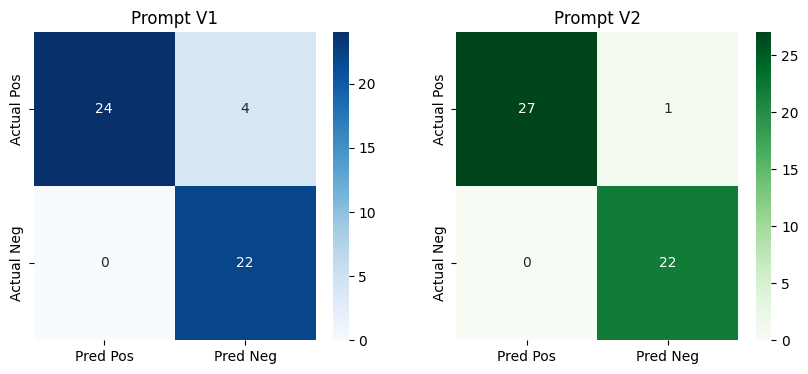

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Pos","Pred Neg"],
            yticklabels=["Actual Pos","Actual Neg"],
            ax=axes[0])

axes[0].set_title("Prompt V1")

sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Pos","Pred Neg"],
            yticklabels=["Actual Pos","Actual Neg"],
            ax=axes[1])

axes[1].set_title("Prompt V2")

plt.show()

## Result Interpretation

Both experiments used the same dataset and LLM model.  
The only difference was the prompt design.

Comparing the results allows us to observe how **prompt engineering affects LLM classification performance**.

In this experiment, the improved prompt produced more consistent predictions and improved overall accuracy.

## References and Resources

The following tools, libraries, and datasets were used during the development of this experiment.

---

### Large Language Models

OpenAI Documentation – Introduction to Large Language Models  
https://platform.openai.com/docs

---

### LLM Model and Inference

**Meta AI – Llama 3 Model**  
https://ai.meta.com/llama/

**Ollama – Local LLM Runtime**  
https://ollama.com

---

### Dataset

Amazon Reviews Dataset (Kaggle Version)  
Halime Doğan.  
https://www.kaggle.com/datasets/halimedogan/amazon-reviews

This dataset is derived from the widely used Amazon Review Dataset:

Ni, J., Li, J., McAuley, J. (2019).  
Justifying Recommendations using Distantly-Labeled Reviews and Fine-Grained Aspects.  
https://nijianmo.github.io/amazon/index.html

---

### Python Libraries Used

**Python Standard Library**

- `os` – Operating system utilities  
  https://docs.python.org/3/library/os.html

- `time` – Timing and performance measurement  
  https://docs.python.org/3/library/time.html

- `re` – Regular expressions for text processing  
  https://docs.python.org/3/library/re.html

---

**Data Processing**

- **Pandas** – Data analysis and manipulation  
  https://pandas.pydata.org/

---

**Machine Learning and Metrics**

- **Scikit-learn** – Machine learning evaluation metrics  
  https://scikit-learn.org/

---

**Visualization**

- **Matplotlib** – Plotting and visualization  
  https://matplotlib.org/

- **Seaborn** – Statistical visualization  
  https://seaborn.pydata.org/

---

### Development Tools

- **Python Programming Language**  
  https://www.python.org/

- **Jupyter Notebook** – Interactive computing environment  
  https://jupyter.org/

- **Visual Studio Code** – Development environment  
  https://code.visualstudio.com/

- **Ollama** – Local inference for LLM models

---

### ML Tools

**Weka Machine Learning Toolkit**  
https://www.cs.waikato.ac.nz/ml/weka/

---